In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from load_data import load_raw_data
from clean_data import clean_data

# Makes charts render inline in the notebook
%matplotlib inline
sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
raw_df = load_raw_data()
df = clean_data(raw_df)
df.head()

TotalCharges: found 11 rows that were blank strings, now proper NaN


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Overall churn rate: 26.5%


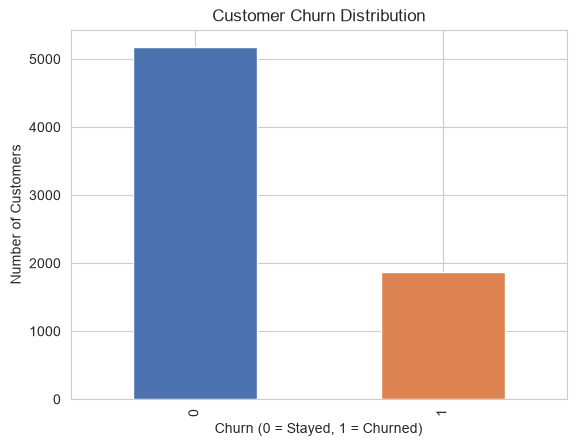

In [3]:
churn_rate = df['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

df['Churn'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


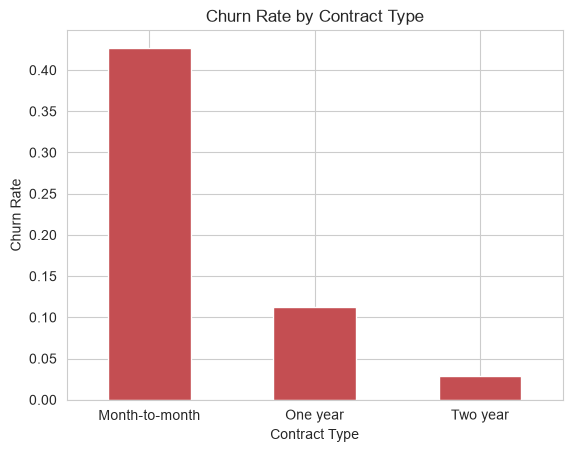

In [4]:
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
print(contract_churn)

contract_churn.plot(kind='bar', color='#C44E52')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.show()

tenure_group
0-1 yr    0.476782
1-2 yr    0.287109
2-4 yr    0.203890
4-6 yr    0.095132
Name: Churn, dtype: float64


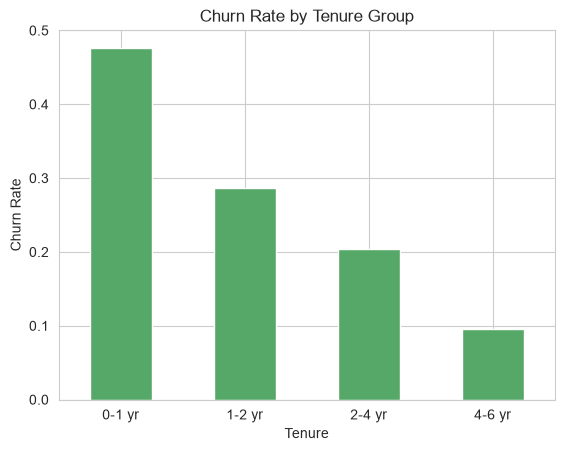

In [5]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                              labels=['0-1 yr', '1-2 yr', '2-4 yr', '4-6 yr'])

tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean()
print(tenure_churn)

tenure_churn.plot(kind='bar', color='#55A868')
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate')
plt.xlabel('Tenure')
plt.xticks(rotation=0)
plt.show()

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64


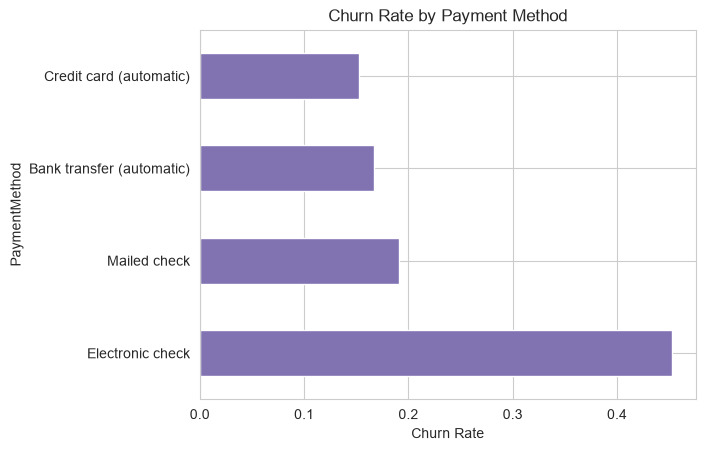

In [6]:
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
print(payment_churn)

payment_churn.plot(kind='barh', color='#8172B2')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate')
plt.show()

In [7]:
print(f"Overall ARPU (avg monthly charge): ${df['MonthlyCharges'].mean():.2f}")
print(f"Overall avg CLTV (total charges so far): ${df['TotalCharges'].mean():.2f}")

Overall ARPU (avg monthly charge): $64.76
Overall avg CLTV (total charges so far): $2279.73


Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64


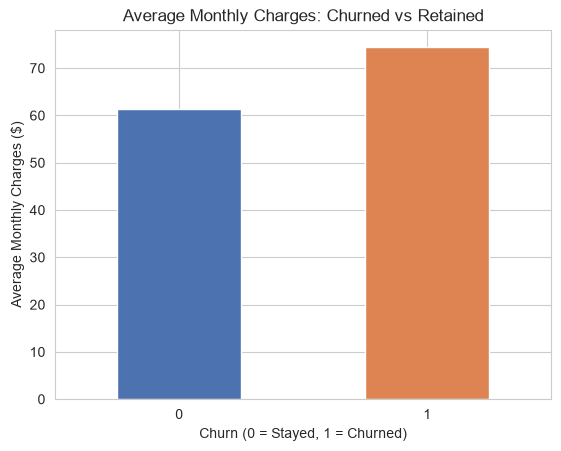

In [8]:
arpu_by_churn = df.groupby('Churn')['MonthlyCharges'].mean()
print(arpu_by_churn)

arpu_by_churn.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Average Monthly Charges: Churned vs Retained')
plt.ylabel('Average Monthly Charges ($)')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.xticks(rotation=0)
plt.show()

In [9]:
monthly_revenue_at_risk = df[df['Churn'] == 1]['MonthlyCharges'].sum()
total_monthly_revenue = df['MonthlyCharges'].sum()
pct_at_risk = monthly_revenue_at_risk / total_monthly_revenue

print(f"Monthly revenue at risk from churned customers: ${monthly_revenue_at_risk:,.2f}")
print(f"Total monthly revenue: ${total_monthly_revenue:,.2f}")
print(f"Percent of revenue at risk: {pct_at_risk:.1%}")

Monthly revenue at risk from churned customers: $139,130.85
Total monthly revenue: $456,116.60
Percent of revenue at risk: 30.5%


In [10]:
from features import build_features
from train_model import prepare_train_test, train_logistic_regression, train_random_forest

features_df = build_features(df)
X_train, X_test, y_train, y_test = prepare_train_test(features_df)

log_model, scaler = train_logistic_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train)

TotalCharges                      0.177221
tenure                            0.165853
MonthlyCharges                    0.152146
Contract_Two year                 0.058075
InternetService_Fiber optic       0.043513
PaymentMethod_Electronic check    0.037340
Contract_One year                 0.030027
OnlineSecurity_Yes                0.028095
gender_Male                       0.025872
PaperlessBilling_Yes              0.023937
dtype: float64


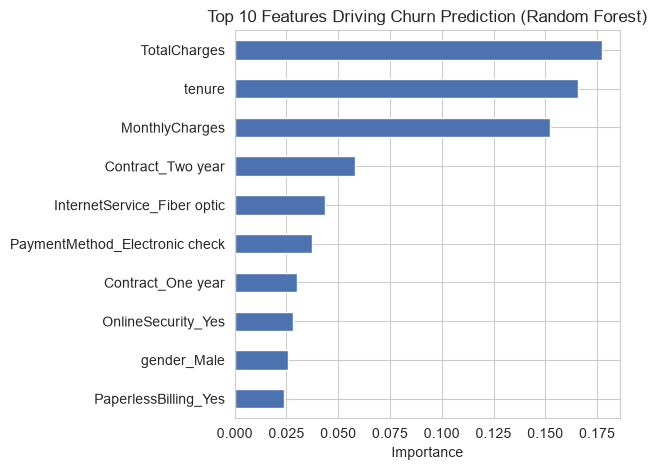

In [11]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)

print(top_features)

top_features.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 10 Features Driving Churn Prediction (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

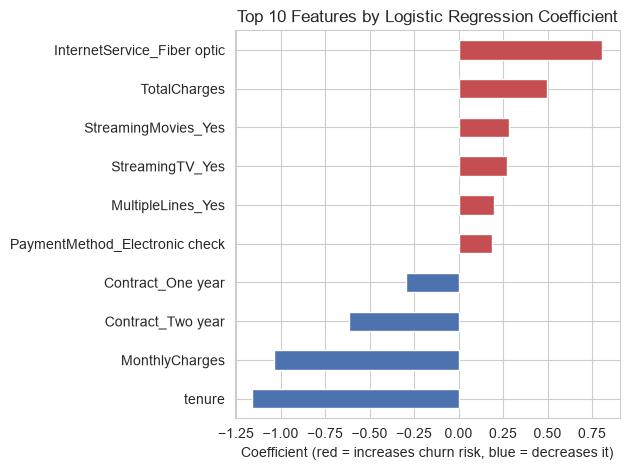

In [12]:
coefficients = pd.Series(log_model.coef_[0], index=X_train.columns)
top_coef = coefficients.abs().sort_values(ascending=False).head(10)
top_coef_signed = coefficients[top_coef.index].sort_values()

colors = ['#C44E52' if x > 0 else '#4C72B0' for x in top_coef_signed]
top_coef_signed.plot(kind='barh', color=colors)
plt.title('Top 10 Features by Logistic Regression Coefficient')
plt.xlabel('Coefficient (red = increases churn risk, blue = decreases it)')
plt.tight_layout()
plt.show()